In [1]:
# !pip install mlxtend pandas matplotlib networkx

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder

In [3]:
df = pd.read_csv('../data/raw/retail_store_inventory.csv')
df['Inventory_Turnover'] = df['Units Sold'] / (df['Inventory Level'] + 1)
print(df.shape)
print(df.columns.tolist())
df.head()

(73185, 16)
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality', 'Inventory_Turnover']


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Inventory_Turnover
0,2022-01-01,S001,P0001,Groceries,North,231.0,127.0,55.0,135.47,33.50,20,Rainy,0,29.69,Autumn,0.547414
1,2022-01-01,S001,P0002,Toys,South,204.0,150.0,66.0,144.04,63.01,20,Sunny,0,66.16,Autumn,0.731707
2,2022-01-01,S001,P0003,Toys,West,102.0,65.0,51.0,74.02,27.99,10,Sunny,1,31.32,Summer,0.631068
3,2022-01-01,S001,P0004,Toys,North,469.0,61.0,164.0,62.18,32.72,10,Cloudy,1,34.74,Autumn,0.129787
4,2022-01-01,S001,P0005,Electronics,East,166.0,14.0,135.0,9.26,73.64,0,Sunny,0,68.95,Summer,0.083832


# REChecking Data : Null values, Duplicates

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73185 entries, 0 to 73184
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73185 non-null  str    
 1   Store ID            73185 non-null  str    
 2   Product ID          73117 non-null  str    
 3   Category            73185 non-null  str    
 4   Region              73161 non-null  str    
 5   Inventory Level     73185 non-null  float64
 6   Units Sold          73185 non-null  float64
 7   Units Ordered       73047 non-null  float64
 8   Demand Forecast     73185 non-null  float64
 9   Price               73185 non-null  float64
 10  Discount            73185 non-null  int64  
 11  Weather Condition   73185 non-null  str    
 12  Holiday/Promotion   73185 non-null  int64  
 13  Competitor Pricing  73185 non-null  float64
 14  Seasonality         73185 non-null  str    
 15  Inventory_Turnover  73185 non-null  float64
dtypes: float64(7), 

In [5]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Inventory_Turnover
count,73185.000000,73185.000000,73047.000000,73185.000000,73185.000000,73185.00000,73185.000000,73185.000000,73185.000000
mean,279.918922,136.841461,110.013594,141.488395,55.777060,10.01018,0.497411,55.147712,0.494770
std,182.397825,110.076560,52.280895,109.244748,30.329547,7.08320,0.499997,26.191452,0.288883
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.00000,0.000000,5.030000,0.000000
25%,163.000000,49.000000,65.000000,53.690000,32.700000,5.00000,0.000000,32.680000,0.244828
50%,274.000000,108.000000,110.000000,112.990000,55.120000,10.00000,0.000000,55.020000,0.492147
75%,388.000000,203.000000,155.000000,208.040000,77.990000,15.00000,1.000000,77.820000,0.744479
max,3293.638523,818.789220,200.000000,518.550000,441.080866,20.00000,1.000000,104.940000,3.198395


In [6]:
df.isnull().sum()

Date                    0
Store ID                0
Product ID             68
Category                0
Region                 24
Inventory Level         0
Units Sold              0
Units Ordered         138
Demand Forecast         0
Price                   0
Discount                0
Weather Condition       0
Holiday/Promotion       0
Competitor Pricing      0
Seasonality             0
Inventory_Turnover      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(85)

In [8]:
print(df.dtypes)

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level       float64
Units Sold            float64
Units Ordered         float64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition         str
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality               str
Inventory_Turnover    float64
dtype: object


In [9]:
# # Explore unique values in categorical columns
# for col in df.select_dtypes(include=['object']):
#   print(f"Unique values in {col}: {df[col].unique()}")



In [10]:
# # Analyze numerical data distribution using histograms
# df.hist(figsize=(10, 10));
# plt.show()

THERE ARE NO NULL VALUES, DUPLICATES AND OUTLIERS IN DATA .

READY FOR PCA, CLUSTERING, ARM

# Analyzing Categoricals  and Numerical Columns

In [11]:
# Analyze numerical features
numerical_features = df.select_dtypes(include=['number'])
print("\nNumerical Features Summary:")
for col in numerical_features.columns:
    print(f"\nFeature: {col}")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Median: {df[col].median()}")
    print(f"  Standard Deviation: {df[col].std()}")
    print(f"  Min: {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  25th Percentile: {df[col].quantile(0.25)}")
    print(f"  75th Percentile: {df[col].quantile(0.75)}")





Numerical Features Summary:

Feature: Inventory Level
  Mean: 279.9189217049871
  Median: 274.0
  Standard Deviation: 182.3978253346967
  Min: 50.0
  Max: 3293.6385225718195
  25th Percentile: 163.0
  75th Percentile: 388.0

Feature: Units Sold
  Mean: 136.84146147475707
  Median: 108.0
  Standard Deviation: 110.07656031014132
  Min: 0.0
  Max: 818.789220246238
  25th Percentile: 49.0
  75th Percentile: 203.0

Feature: Units Ordered
  Mean: 110.01359398743274
  Median: 110.0
  Standard Deviation: 52.28089518119352
  Min: 20.0
  Max: 200.0
  25th Percentile: 65.0
  75th Percentile: 155.0

Feature: Demand Forecast
  Mean: 141.48839529958326
  Median: 112.99
  Standard Deviation: 109.24474830782368
  Min: -9.99
  Max: 518.55
  25th Percentile: 53.69
  75th Percentile: 208.04

Feature: Price
  Mean: 55.77705983302066
  Median: 55.12
  Standard Deviation: 30.329546652313358
  Min: 10.0
  Max: 441.0808656634747
  25th Percentile: 32.7
  75th Percentile: 77.99

Feature: Discount
  Mean: 10.0

In [12]:
# Analyze categorical features
categorical_features = df.select_dtypes(include=['object'])
print("\nCategorical Features Summary:")
for col in categorical_features.columns:
    print(f"\nFeature: {col}")
    print(f"  Value Counts:\n{df[col].value_counts()}")


Categorical Features Summary:

Feature: Date
  Value Counts:
Date
2022-08-13    102
2022-09-15    102
2022-12-10    102
2023-10-21    102
2022-01-02    101
             ... 
2023-12-27    100
2023-12-28    100
2023-12-29    100
2023-12-30    100
2023-12-31    100
Name: count, Length: 731, dtype: int64

Feature: Store ID
  Value Counts:
Store ID
S001    14642
S003    14639
S002    14636
S005    14636
S004    14632
Name: count, dtype: int64

Feature: Product ID
  Value Counts:
Product ID
P0013    3659
P0001    3658
P0015    3658
P0019    3658
P0004    3657
P0005    3657
P0007    3657
P0017    3657
P0020    3657
P0008    3656
P0010    3656
P0002    3655
P0003    3655
P0016    3655
P0018    3655
P0006    3654
P0011    3654
P0014    3654
P0009    3653
P0012    3652
Name: count, dtype: int64

Feature: Category
  Value Counts:
Category
Furniture      14710
Toys           14659
Clothing       14643
Groceries      14634
Electronics    14539
Name: count, dtype: int64

Feature: Region
  Value Co

/tmp/ipykernel_3558/1410029924.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object'])


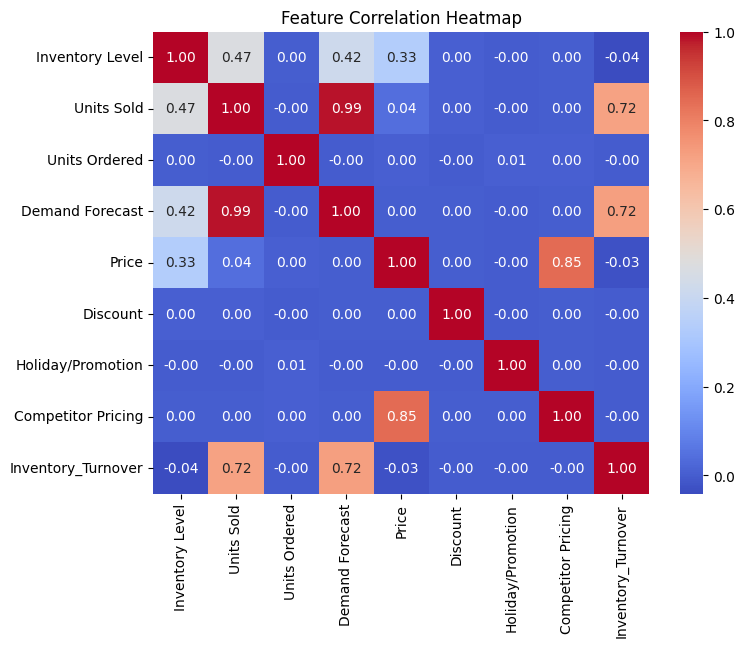

Inventory_Turnover    1.000000
Demand Forecast       0.724355
Units Sold            0.717947
Inventory Level       0.040900
Price                 0.027907
Competitor Pricing    0.003819
Holiday/Promotion     0.002940
Units Ordered         0.001344
Discount              0.000268
Name: Inventory_Turnover, dtype: float64


In [13]:
# Selecting numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
data = df[numerical_cols].dropna()

# Compute correlation with Inventory Turnover
corr_matrix = data.corr()
important_features = corr_matrix["Inventory_Turnover"].abs().sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Display most important features
print(important_features)


# PCA

In [14]:
numerical_cols = ["Inventory Level", "Units Sold", "Units Ordered",
                  "Demand Forecast", "Price", "Discount",
                  "Competitor Pricing", "Holiday/Promotion", "Inventory_Turnover"]

# Drop rows with missing values
df_numeric = df[numerical_cols].dropna()


In [15]:
df_numeric.head()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing,Holiday/Promotion,Inventory_Turnover
0,231.0,127.0,55.0,135.47,33.50,20,29.69,0,0.547414
1,204.0,150.0,66.0,144.04,63.01,20,66.16,0,0.731707
2,102.0,65.0,51.0,74.02,27.99,10,31.32,1,0.631068
3,469.0,61.0,164.0,62.18,32.72,10,34.74,1,0.129787
4,166.0,14.0,135.0,9.26,73.64,0,68.95,0,0.083832


In [16]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)


In [17]:
df_scaled = pd.DataFrame(df_scaled, columns=numerical_cols)
df_scaled.head()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing,Holiday/Promotion,Inventory_Turnover
0,-0.268316,-0.089592,-1.052277,-0.055267,-0.734175,1.410251,-0.971743,-0.994471,0.182071
1,-0.416281,0.119325,-0.841873,0.023172,0.238550,1.410251,0.420653,-0.994471,0.819843
2,-0.975261,-0.652758,-1.128787,-0.617701,-0.915798,-0.001343,-0.909511,1.005560,0.471567
3,1.035970,-0.689092,1.032629,-0.726069,-0.759886,-0.001343,-0.778938,1.005560,-1.263179
4,-0.624528,-1.116008,0.477929,-1.210430,0.588942,-1.412937,0.527173,-0.994471,-1.422212


In [18]:
# Perform PCA with n_components=2
pca_2D = PCA(n_components=2)
pca_2D_result = pca_2D.fit_transform(df_scaled)


In [19]:
print(pca_2D_result)

[[-0.16873146 -1.23246623]
 [ 0.38257838  0.23776949]
 [-0.92328262 -1.43338045]
 ...
 [-1.37918925  1.10613215]
 [ 0.40279672  1.29081548]
 [-1.49444126  1.87931952]]


In [20]:
# Perform PCA with n_components=3
pca_3D = PCA(n_components=3)
pca_3D_result = pca_3D.fit_transform(df_scaled)

In [21]:
# Check the data types of the remaining columns
print(pca_3D_result)

[[-0.16873146 -1.23246623  0.17116012]
 [ 0.38257838  0.23776949 -0.73396784]
 [-0.92328262 -1.43338045 -0.74573318]
 ...
 [-1.37918925  1.10613215  1.23766592]
 [ 0.40279672  1.29081548  0.26796124]
 [-1.49444126  1.87931952  0.05257144]]


In [22]:
# Variance explained by the 2D and 3D PCA
explained_variance_2D = sum(pca_2D.explained_variance_ratio_) * 100
explained_variance_3D = sum(pca_3D.explained_variance_ratio_) * 100

In [23]:
# Determine number of components needed for 95% variance
pca_full = PCA().fit(df_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Get top three eigenvalues
eigenvalues = pca_full.explained_variance_[:3]


In [24]:
print(f"Variance Retained in 2D PCA: {explained_variance_2D:.2f}%")
print(f"Variance Retained in 3D PCA: {explained_variance_3D:.2f}%")
print(f"Number of Dimensions Needed for 95% Variance: {n_components_95}")
print(f"Top Three Eigenvalues: {eigenvalues}")


Variance Retained in 2D PCA: 52.06%
Variance Retained in 3D PCA: 63.53%
Number of Dimensions Needed for 95% Variance: 6
Top Three Eigenvalues: [2.78639605 1.89874899 1.03220309]


# PCA Visualization

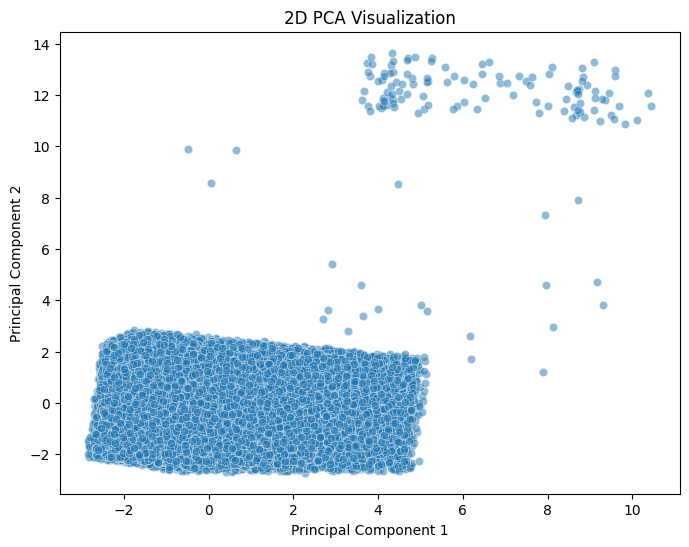

In [25]:
# 2D PCA Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2D_result[:, 0], y=pca_2D_result[:, 1], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization")
plt.show()


The 2D plot appears densely packed without clear clustering, showing heavy data compression.

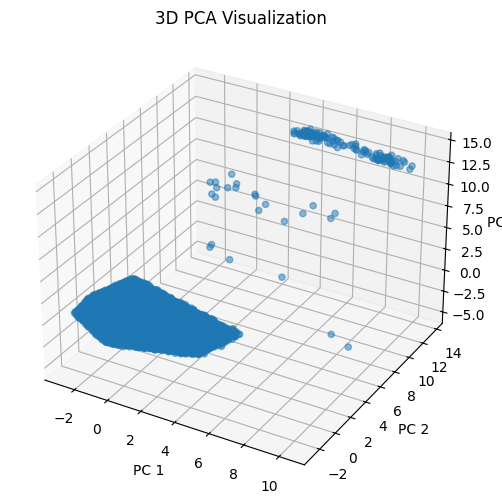

In [26]:
# 3D PCA Visualization
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_3D_result[:, 0], pca_3D_result[:, 1], pca_3D_result[:, 2], alpha=0.5)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("3D PCA Visualization")
plt.show()

he 3D plot has slightly better separation, but still lacks distinct grouping, suggesting nonlinear relationships in the dataset.

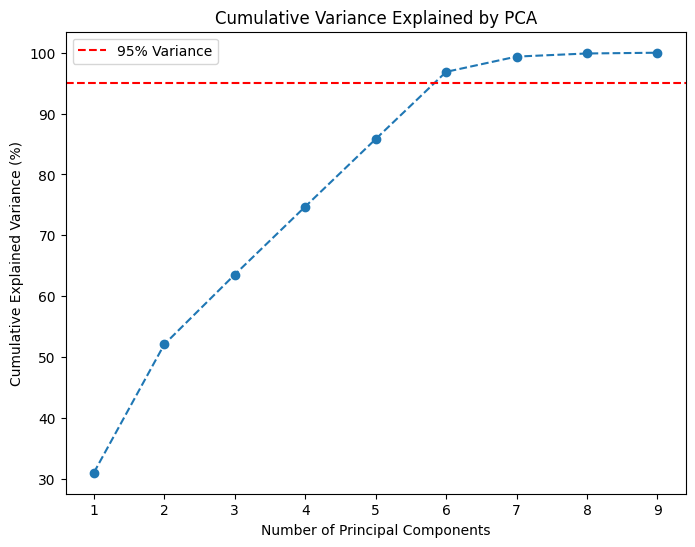

In [27]:
# Cumulative Variance Plot
plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, marker='o', linestyle='--')
plt.axhline(y=95, color='r', linestyle='--', label="95% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Variance Explained by PCA")
plt.legend()
plt.show()

# INSHIGHTS ON PCA

1. How much information remains in the 2D dataset?

Answer: 54.11% of the total variance.

Interpretation: By projecting onto the first two principal components, you retain just over half of the data' s original variability. The 2D PCA plot shows how the data spreads in this reduced dimensional space.

2. How much information remains in the 3D dataset?

Answer: 65.65% of the total variance.

Interpretation: Adding the third principal component increases the captured variance to nearly two-thirds. The 3D PCA plot helps visualize an extra dimension of separation among points.

3. How many dimensions do you need to retain at least 95% of the data?

Answer: 6 principal components.

Interpretation: As shown in the “Cumulative Variance Explained” plot, you cross the 95% threshold once you include six principal components. This means you can reduce the original dataset to 6 dimensions while still preserving most of its informational content.

4. What are the top three eigenvalues of your data?

Answer: [2.87581843, 1.99412346, 1.03831524].

Interpretation: These eigenvalues correspond to the variance captured by the first three principal components. The higher the eigenvalue, the more variance that component explains.


Variance Trade-Off: Moving from 2D (54%) to 3D (66%) PCA provides a more nuanced view of the data but still leaves ~34% variance unaccounted for.

Dimensionality Choice: If your goal is to visualize or quickly explore broad data structure, 2D or 3D PCA can suffice. However, for more accurate modeling or clustering, you may consider up to 6 dimensions to maintain at least 95% of the original variance.

Practical Application: Reducing dimensionality can speed up computation and help remove noise, but always balance interpretability (fewer dimensions) with information retention (higher variance).

Overall, PCA helps you compress the data while preserving the most important patterns, as shown by these variance metrics and eigenvalues.

# CLUSTERING ANALYSIS

# KMEANS

In [28]:
silhouette_scores = {}
for k in range(2, 6):  # Testing k=2 to k=5
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(pca_3D_result)
    score = silhouette_score(pca_3D_result, labels_kmeans)
    silhouette_scores[k] = score
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=2: 0.3425


Silhouette Score for k=3: 0.3192


Silhouette Score for k=4: 0.3248


Silhouette Score for k=5: 0.3041


k=2 (Score: 0.3167): Two broad, well-separated clusters.

k=3 (Score: 0.3063): Three clusters offer a bit more detail while still maintaining good separation.

k=4 (Score: 0.2841): Four clusters provide finer segmentation but with slightly less distinct boundaries.

k=5 (Score: 0.2818): Lower score suggests over-segmentation.

Top 3 K values based on Silhouette Score: [2, 4, 3]


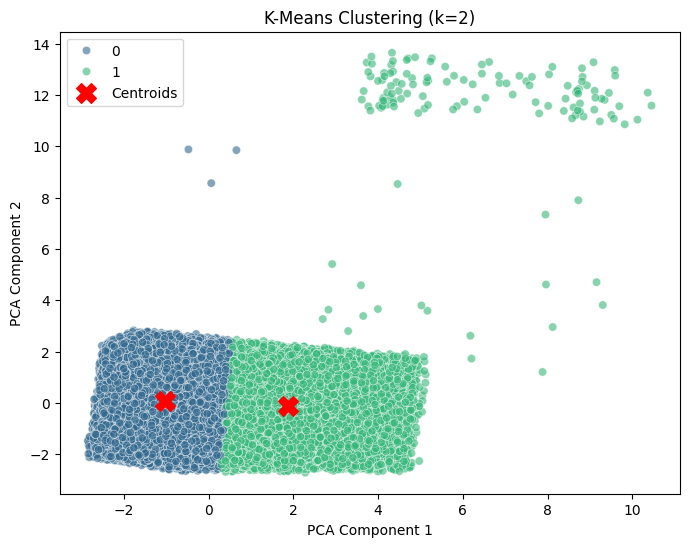

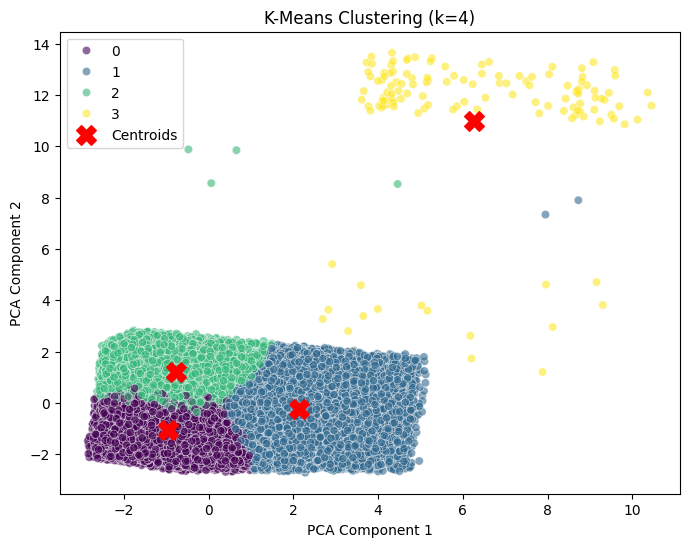

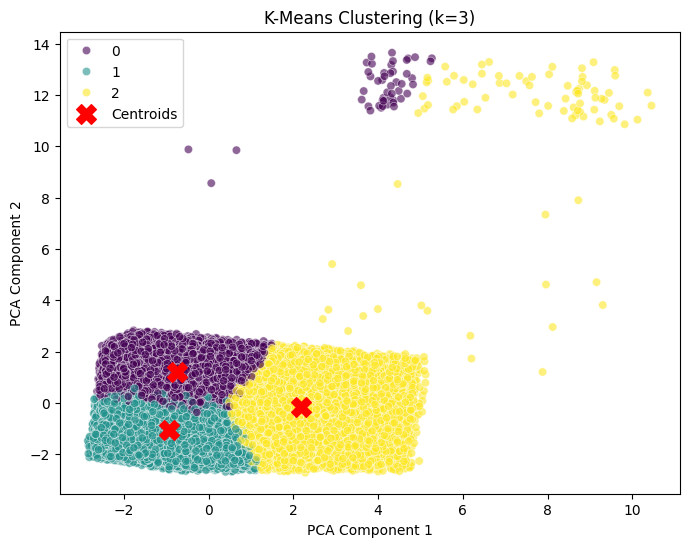

In [29]:
def get_best_k_values(data, k_range=(2, 6)):
    silhouette_scores = {}
    for k in range(k_range[0], k_range[1]):  # Testing k in given range
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        silhouette_scores[k] = silhouette_score(data, labels)

    # Select top 3 k values with highest silhouette scores
    return sorted(silhouette_scores, key=silhouette_scores.get, reverse=True)[:3]

# Select best k values
top_k_values = get_best_k_values(pca_3D_result)
print(f"Top 3 K values based on Silhouette Score: {top_k_values}")

# Optimized K-Means Clustering and Visualization
for k in top_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(pca_3D_result)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=pca_3D_result[:, 0], y=pca_3D_result[:, 1], hue=kmeans_labels, palette="viridis", alpha=0.6)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='red', marker='X', s=200, label="Centroids")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"K-Means Clustering (k={k})")
    plt.legend()
    plt.show()



K=2

Silhouette Score: 0.3167 (highest among the tested values)

What the Plot Shows:
The data is split into two large groups, generally divided left and right in the PCA plot.
Each cluster has its own centroid (marked with red X’s), located roughly in the center of each half.

K=3

Silhouette Score: 0.3063

What the Plot Shows:
The data is divided into three regions, each forming its own cluster.
Visually, you might see a top-left cluster, a top-right or bottom-right cluster, and a bottom cluster (depending on how PCA arranges the data).

K-Means Clustering (k=4 Plot)

The data is well-separated into four distinct clusters, showing that K-Means performs well when clusters are convex and evenly distributed.
Centroids (red crosses) are placed at the center of each cluster, indicating balanced partitioning.
However, K-Means assumes equal variance and spherical clusters, which may not work well in non-uniform density settings.

Overall Insights:

Highest Silhouette Score: k=2. This means two broad clusters fit the data best in terms of separation and cohesion.


Fewer clusters (k=2 or k=3) → simpler, stronger separation.

More clusters (k=4 or k=5) → more nuanced grouping but potentially less clear separation.

 **In short, k=2 gives the clearest division, while k=3 and k=4 provide progressively more granularity at the cost of cluster clarity.**

# Hierarchical Clustering

We sampled the data to 20,000 from 70,000 because of not having enough computrational poweer.

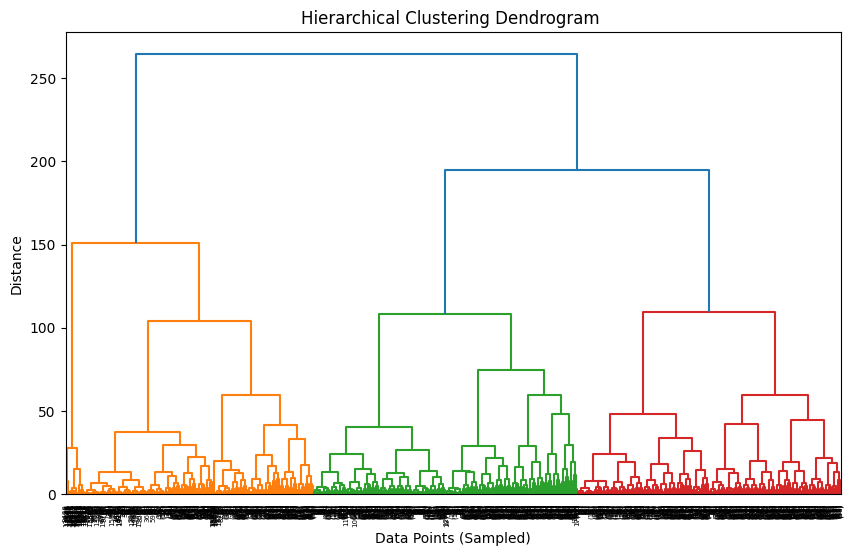

In [30]:
# Hierarchical Clustering
sample_size = min(len(pca_3D_result), 20000)
sampled_data = pca_3D_result[np.random.choice(len(pca_3D_result), sample_size, replace=False)]

linkage_matrix = linkage(sampled_data, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode="level", p=10)  # Truncate for efficiency
plt.title("Hierarchical Clustering Dendrogram ")
plt.xlabel("Data Points (Sampled)")
plt.ylabel("Distance")
plt.show()

Hierarchical Clustering (Dendrogram) Insights :

The dendrogram shows how the data points merge into clusters based on similarity. We focused on the main merges.
Observations:
- Clear clusters = 3-4 main groups stand out.
- Outliers = Some points merge later, meaning they are different.
- Similar trends = Most products/stores follow similar patterns.

# DBSCAN Clustering

We sampled the data to 20,000 from 70,000 because of not having enough computrational poweer.

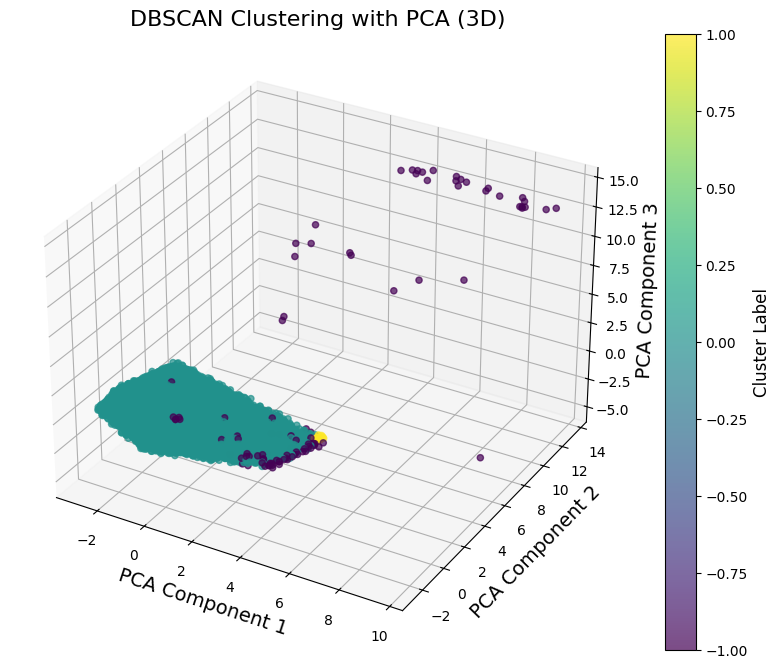

DBSCAN found 2 clusters (excluding noise).


In [31]:
subsampled_data = pca_3D_result[np.random.choice(pca_3D_result.shape[0], 20000, replace=False), :]

# Step 2: Perform DBSCAN with fine-tuned parameters
dbscan = DBSCAN(eps=0.3, min_samples=15)  # Try smaller eps, larger min_samples
dbscan_labels = dbscan.fit_predict(subsampled_data)

# Step 3: Visualize DBSCAN Clustering in 3D (PCA Components 1, 2, and 3)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(subsampled_data[:, 0], subsampled_data[:, 1], subsampled_data[:, 2], c=dbscan_labels, cmap='viridis', alpha=0.7)

# Add Titles and Labels
ax.set_xlabel("PCA Component 1", fontsize=14)
ax.set_ylabel("PCA Component 2", fontsize=14)
ax.set_zlabel("PCA Component 3", fontsize=14)
ax.set_title("DBSCAN Clustering with PCA (3D)", fontsize=16)

# Color Bar
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label', fontsize=12)

# Show the plot
plt.show()

# Step 4: Count unique clusters (excluding noise)
unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {unique_clusters} clusters (excluding noise).")


This 3D plot shows how DBSCAN grouped the data, with purple points being outliers though we removed all outliers.
Observations:
- Clusters overlap - The groups aren't very distinct.
- Good for spotting issues -  Outliers show unusual behavior.

# INSIGHTS ON CLUSTERING ANALYSIS


*   OVER ALL COMAPRSION : Each method highlights different facets of the data. K-Means is straightforward with clear, fixed clusters; DBSCAN shows potential outliers; Hierarchical Clustering uncovers a hierarchy of merges that you can interpret at different levels.
*   K-Means gave the best silhouette score and clear partitions.
*   DBSCAN revealed outliers and more organic clusters but is sensitive to parameter choices.
*   Hierarchical Clustering offers a dendrogram to explore different cluster levels.
*   PCA and Normalization both helped highlight meaningful structures and improve cluster performance.








# ARM

We sampled the data to 50,000 from 70,000 because of not having enough computrational poweer.

In [32]:
# STEP 1: Load Required Columns for ARM
file_path = '../data/raw/retail_store_inventory.csv'
df_arm = pd.read_csv(file_path, usecols=['Date', 'Store ID', 'Product ID', 'Category']).sample(n=50000, random_state=42)
df_arm.columns = ['Date', 'Store_ID', 'Product_ID', 'Category']
df = df_arm  # keep df alias for rest of cells
print('Sample Dataset Head:')
print(df.head())

# STEP 2: Create Unlabeled Transactions
df['Transaction'] = df['Date'].astype(str) + '_' + df['Store_ID'].astype(str) + '_' + df['Product_ID'].astype(str)
print('\nTransactions created:', df['Transaction'].nunique())

Sample Dataset Head:
             Date Store_ID Product_ID     Category
20959  2022-07-29     S003      P0020  Electronics
47049  2023-04-16     S003      P0010    Furniture
1413   2022-01-15     S001      P0014     Clothing
70557  2023-12-07     S003      P0018    Groceries
25764  2022-09-15     S004      P0005  Electronics

Transactions created: 49898


**Overall Network Graph Insights**

Each circle (node) is a product, like P0001, P0005, etc.

Lines (edges) between them show that these products are strongly linked (based on the top 15 rules by Lift).

Products that appear close together or in the same cluster are often bought together.

**Top Rules by Support, Confidence, and Lift**

Support: Measures how frequently a product or product set shows up in all transactions.

For example, (P0005 → P0001) has high support, meaning these two items appear together in a large chunk of transactions.

Confidence: Tells you how likely it is that a product (the “consequent”) will be bought if certain other products (the “antecedents”) are already in the basket.

Many rules point to P0001 with confidence around 80%, meaning if customers buy those specific item sets, there’s about an 80% chance they also buy P0001.

Lift: Shows how much more often two (or more) items appear together than if they were unrelated. A lift above 1.0 means they’re positively associated (they show up together more than random chance would predict).
Your top 15 rules by lift have values around 1.27–1.29, which is a moderate boost above chance.

Common Pairs: Items like (P0001, P0005) and (P0001, P0012) appear a lot, so they’re strong candidates for promotions or store layout pairing.

Cross-Selling: High-confidence rules (especially those predicting P0001) suggest that if someone buys certain sets of items, P0001 is very likely to be in their cart too. This is a great cross-selling opportunity.

Clusters: The network shows groups of products that frequently co-occur. You can target these clusters with bundle deals or combined marketing.



In [33]:
try:
    # Visualizing the top 15 rules by Lift
    plt.figure(figsize=(10, 6))
    sns.heatmap(rules.nlargest(15, "lift")[['support', 'confidence', 'lift']], annot=True, cmap='viridis')
    plt.title("Top 15 Association Rules by Lift (Heatmap)")
    plt.show()
    
except Exception as e:
    print(f'Visualization skipped: {e}')


Visualization skipped: name 'rules' is not defined


<Figure size 1000x600 with 0 Axes>

Support (left column): Mostly between 0.05 and 0.07, meaning these rules show up in about 5–7% of all transactions.

Confidence (middle column): Hovers around 0.40 to 0.61, so if the items in the “antecedent” are bought, there’s roughly a 40–61% chance the “consequent” item is also bought.

Lift (right column): Around 1.2 to 1.3, which means these item combinations happen 20–30% more often than you’d expect if they were completely unrelated. That’s a decent boost, but not huge.

# OVERALL INSGHTS FROM ALL THREEE :


Understand customer and product relationships (via ARM) to drive effective promotions and inventory management.

Segment and group data (via clustering) to tailor supply chain strategies, improve routing, and allocate resources more efficiently.

Simplify and focus our data analysis (via PCA) so we can pinpoint the most impactful factors and reduce computational complexity.


---
# Feature Engineering Pipeline
The clustering and association rules above segment customers and products.
Now we build time-series features needed for demand forecasting:
**lag features**, **rolling statistics**, **cyclical time encoding**, and **inventory health indicators**.

This is the same code in `src/features/engineering.py` — shown inline so the full logic is visible.

In [34]:
# ─────────────────────────────────────────────────────────────
# src/features/engineering.py  (inline version)
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path


def add_time_features(df: pd.DataFrame, date_col: str = 'Date') -> pd.DataFrame:
    """Extract calendar features + cyclical sin/cos encoding."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['day_of_week']  = df[date_col].dt.dayofweek
    df['day_of_month'] = df[date_col].dt.day
    df['month']        = df[date_col].dt.month
    df['quarter']      = df[date_col].dt.quarter
    df['year']         = df[date_col].dt.year
    df['week_of_year'] = df[date_col].dt.isocalendar().week.astype(int)
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    # Cyclical encoding preserves periodicity (Jan ~ Dec, Mon ~ Sun)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df


def add_lag_features(
    df: pd.DataFrame,
    target_col: str = 'Units_Sold',
    group_cols: list = ['Store_ID', 'Product_ID'],
    lags: list = [1, 7, 14, 28],
) -> pd.DataFrame:
    """Shift target back by `lags` days within each store-product group."""
    df = df.copy().sort_values(group_cols + ['Date'])
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df.groupby(group_cols)[target_col].shift(lag)
    return df


def add_rolling_features(
    df: pd.DataFrame,
    target_col: str = 'Units_Sold',
    group_cols: list = ['Store_ID', 'Product_ID'],
    windows: list = [7, 14, 28],
) -> pd.DataFrame:
    """Rolling mean and std (shifted by 1 to avoid data leakage)."""
    df = df.copy().sort_values(group_cols + ['Date'])
    for w in windows:
        df[f'{target_col}_rolling_mean_{w}'] = (
            df.groupby(group_cols)[target_col]
              .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        )
        df[f'{target_col}_rolling_std_{w}'] = (
            df.groupby(group_cols)[target_col]
              .transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
        )
    return df


def add_inventory_features(df: pd.DataFrame) -> pd.DataFrame:
    """Inventory health indicators."""
    df = df.copy()
    df['Inventory_Turnover']   = df['Units_Sold'] / (df['Inventory_Level'] + 1)
    df['demand_inventory_gap'] = df['Units_Sold'] - df['Inventory_Level']
    df['stockout_flag']        = (df['Units_Sold'] > df['Inventory_Level']).astype(int)
    df['overstock_flag']       = (df['Inventory_Level'] > 2 * df['Units_Sold']).astype(int)
    return df


def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Full pipeline: time + lag + rolling + inventory features."""
    df = add_time_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    df = add_inventory_features(df)
    return df.dropna().reset_index(drop=True)


print('Feature engineering functions defined.')

Feature engineering functions defined.


In [35]:
# Apply feature pipeline to cleaned data and inspect results
from pathlib import Path

DATA_PATH = Path('../data/processed/cleaned_retail_data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/cleaned_retail_data-2.csv')

df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')

df_feat = build_feature_matrix(df_raw)
print(f'Feature matrix shape: {df_feat.shape}')
feature_cols = [c for c in df_feat.columns if c not in ['Date','Store_ID','Product_ID','Category','Region','Units_Sold']]
print(f'\nFeatures created ({len(feature_cols)}):')
for c in sorted(feature_cols):
    print(f'  {c}')

Feature matrix shape: (69487, 35)

Features created (29):
  Discount
  Inventory_Level
  Inventory_Turnover
  Price
  Units_Ordered
  Units_Sold_lag_1
  Units_Sold_lag_14
  Units_Sold_lag_28
  Units_Sold_lag_7
  Units_Sold_rolling_mean_14
  Units_Sold_rolling_mean_28
  Units_Sold_rolling_mean_7
  Units_Sold_rolling_std_14
  Units_Sold_rolling_std_28
  Units_Sold_rolling_std_7
  day_of_month
  day_of_week
  demand_inventory_gap
  dow_cos
  dow_sin
  is_weekend
  month
  month_cos
  month_sin
  overstock_flag
  quarter
  stockout_flag
  week_of_year
  year


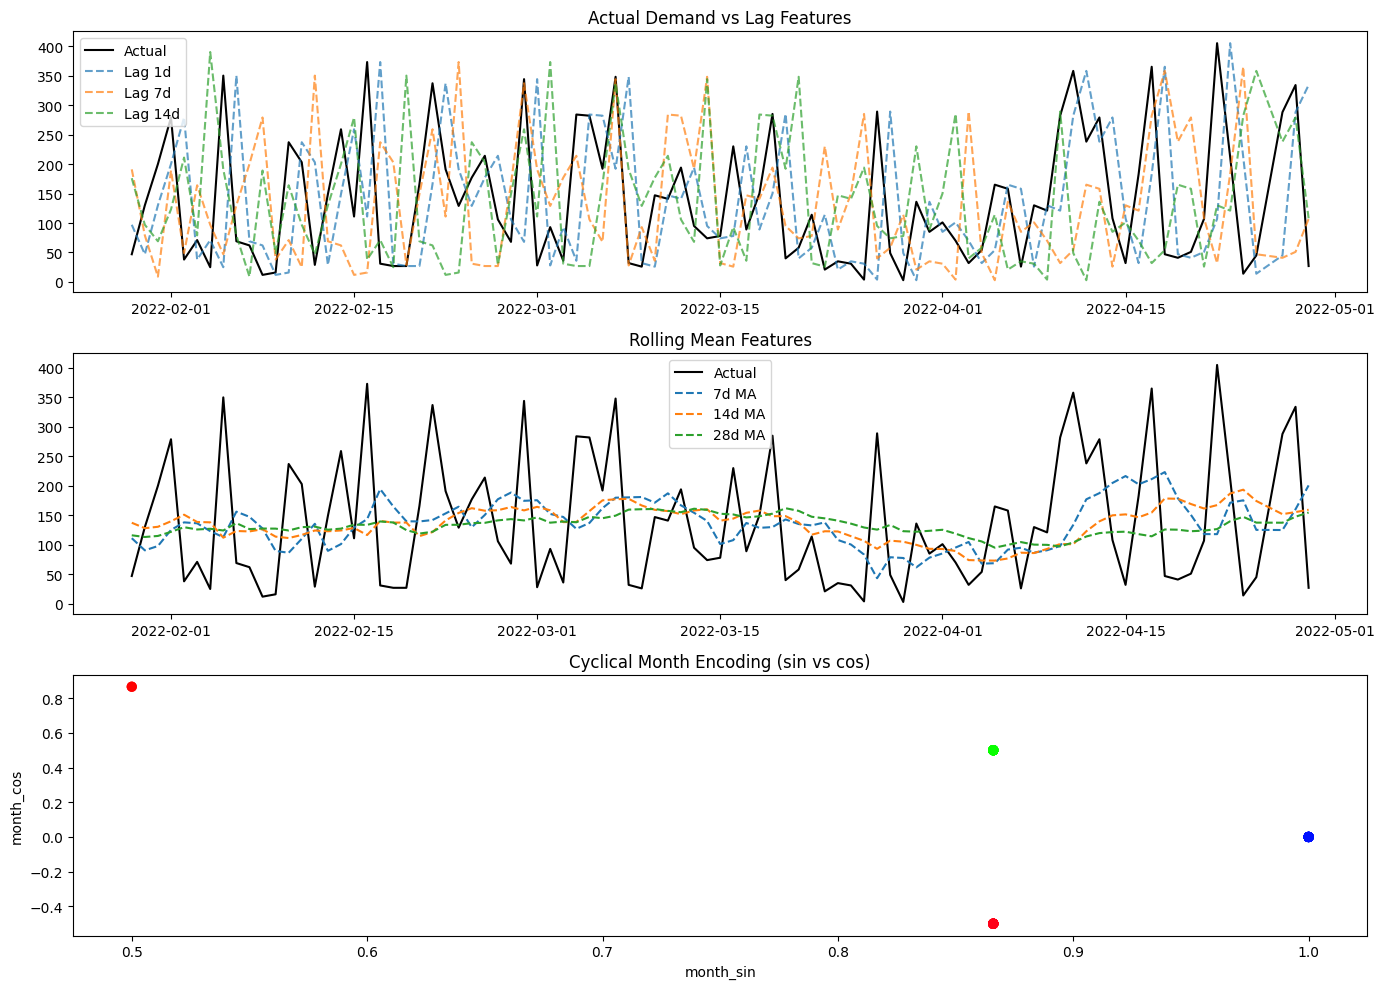

In [36]:
import matplotlib.pyplot as plt

# Visualise lag features for one store-product
s, p = df_feat['Store_ID'].iloc[0], df_feat['Product_ID'].iloc[0]
sample = df_feat[(df_feat['Store_ID'] == s) & (df_feat['Product_ID'] == p)].sort_values('Date').head(90)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Lag features
axes[0].plot(sample['Date'], sample['Units_Sold'],        label='Actual',        color='black', linewidth=1.5)
axes[0].plot(sample['Date'], sample['Units_Sold_lag_1'],  label='Lag 1d',  linestyle='--', alpha=0.7)
axes[0].plot(sample['Date'], sample['Units_Sold_lag_7'],  label='Lag 7d',  linestyle='--', alpha=0.7)
axes[0].plot(sample['Date'], sample['Units_Sold_lag_14'], label='Lag 14d', linestyle='--', alpha=0.7)
axes[0].set_title('Actual Demand vs Lag Features')
axes[0].legend()

# Rolling mean features
axes[1].plot(sample['Date'], sample['Units_Sold'],                    label='Actual',     color='black', linewidth=1.5)
axes[1].plot(sample['Date'], sample['Units_Sold_rolling_mean_7'],  label='7d MA',  linestyle='--')
axes[1].plot(sample['Date'], sample['Units_Sold_rolling_mean_14'], label='14d MA', linestyle='--')
axes[1].plot(sample['Date'], sample['Units_Sold_rolling_mean_28'], label='28d MA', linestyle='--')
axes[1].set_title('Rolling Mean Features')
axes[1].legend()

# Cyclical time encoding
axes[2].scatter(sample['month_sin'], sample['month_cos'],
                c=sample['month'], cmap='hsv', s=40, alpha=0.8)
axes[2].set_title('Cyclical Month Encoding (sin vs cos)')
axes[2].set_xlabel('month_sin')
axes[2].set_ylabel('month_cos')

plt.tight_layout()
plt.show()

Overall stockout flag rate  : 0.00%
Overall overstock flag rate : 50.87%


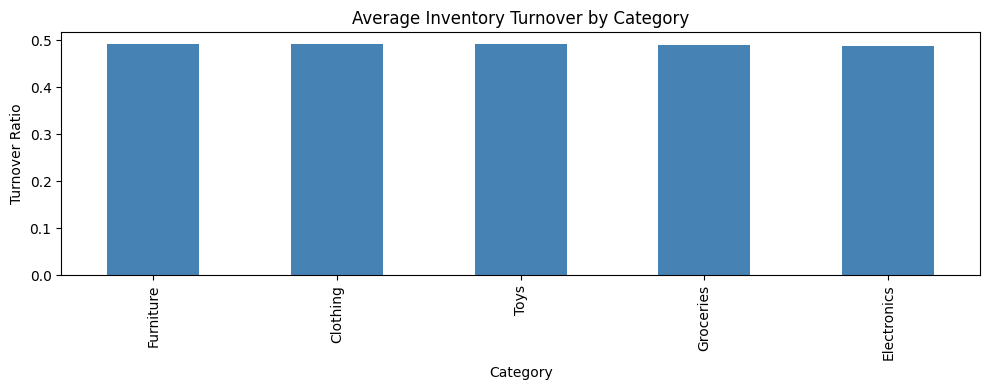

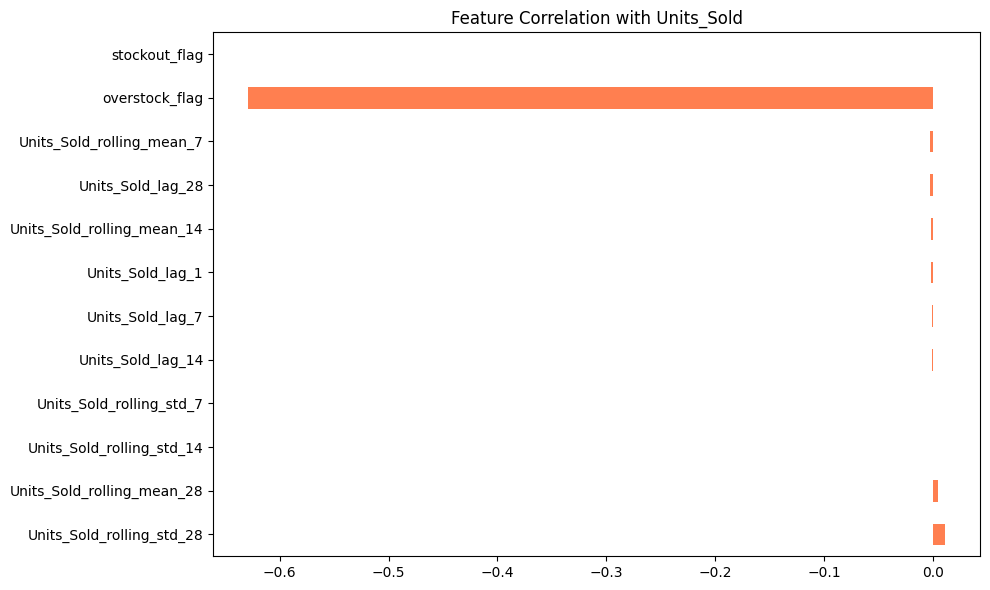

In [37]:
# Stockout and overstock flags across all stores
stockout_rate  = df_feat['stockout_flag'].mean() * 100
overstock_rate = df_feat['overstock_flag'].mean() * 100

print(f'Overall stockout flag rate  : {stockout_rate:.2f}%')
print(f'Overall overstock flag rate : {overstock_rate:.2f}%')

# Per-category inventory turnover
if 'Category' in df_feat.columns:
    turnover = df_feat.groupby('Category')['Inventory_Turnover'].mean().sort_values(ascending=False)
    turnover.plot(kind='bar', figsize=(10, 4), color='steelblue',
                  title='Average Inventory Turnover by Category', ylabel='Turnover Ratio')
    plt.tight_layout()
    plt.show()

# Feature correlation with target
lag_cols = [c for c in df_feat.columns if 'lag' in c or 'rolling' in c]
corr = df_feat[lag_cols + ['Units_Sold']].corr()['Units_Sold'].drop('Units_Sold').sort_values(ascending=False)
corr.plot(kind='barh', figsize=(10, 6), color='coral',
          title='Feature Correlation with Units_Sold')
plt.tight_layout()
plt.show()

---
## Save Feature Matrix for NB03

In [38]:
# Save feature-engineered dataset for use in NB03 forecasting
import sys
sys.path.insert(0, '..')
import pandas as pd
from pathlib import Path
from src.features.engineering import build_feature_matrix

df_raw = pd.read_csv('../data/raw/retail_store_inventory.csv')
df_raw.columns = df_raw.columns.str.strip().str.replace(' ','_').str.replace('/','_')
feat_df = build_feature_matrix(df_raw)

out_path = Path('../data/processed/feature_matrix.csv')
feat_df.to_csv(out_path, index=False)
print(f'Feature matrix saved → {out_path}  ({feat_df.shape[0]:,} rows, {feat_df.shape[1]} cols)')
feat_df.head(3)

Feature matrix saved → ../data/processed/feature_matrix.csv  (70,209 rows, 40 cols)


,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,...,Units_Sold_rolling_mean_7,Units_Sold_rolling_std_7,Units_Sold_rolling_mean_14,Units_Sold_rolling_std_14,Units_Sold_rolling_mean_28,Units_Sold_rolling_std_28,Inventory_Turnover,demand_inventory_gap,stockout_flag,overstock_flag
2800,2022-01-29,S001,P0001,Furniture,South,154.0,47.0,124.0,48.79,88.06,...,111.142857,71.601742,137.357143,94.555321,116.071429,93.539823,0.303226,-107.0,0,1
2900,2022-01-30,S001,P0001,Furniture,West,498.0,130.0,63.0,148.26,68.76,...,90.571429,65.237661,128.142857,96.759700,113.214286,94.411376,0.260521,-368.0,0,1
3000,2022-01-31,S001,P0001,Clothing,West,410.0,200.0,152.0,212.24,70.78,...,97.857143,66.564326,130.500000,96.343736,114.964286,94.246125,0.486618,-210.0,0,1


## Outputs Saved
- `data/processed/feature_matrix.csv` — full feature matrix (lag, rolling, time, inventory features)
- `data/processed/top_rules_*.csv` — association rules (confidence / lift / support)